# Реализация модернизированной FCN сети
В этом уроке мы создадим модернизированную FCN модель с использованием изученных слоёв, которая потенциально должна выдвать более высокое качество на реальных задачах по семантической сегментации.

### Загрузка необходимых библиотек
Здесь мы загружаем разоичные библиотеки, включая TensoFlow.


In [1]:
import numpy as np

import tensorflow as tf
# tf.enable_eager_execution()
print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.19.0


### Создание FCN модели
Для создания модели создадим собственный класс, наследованный от `tf.keras.Model`.
Ранее мы использовали лишь свёртки и пулинги для извлечения признаков и понижения пространственных размерностий. Это был наш Энкодер. В качестве Декодера у нас был простой Upscale слой, который просто расширял изображение до нужного размера. Теперь же давайте реализуем более качественный Декодер с использованием слоёв для повышения разрешения.

В примере ниже будем использовать Unpooling (в керасе это делает слой `tf.keras.layers.UpSampling2D`) перемежающиийся со свёрточными слоями.

In [2]:
class Model(tf.keras.Model):
    def __init__(self):
        super().__init__()
        self.conv1 = tf.keras.layers.Conv2D(64, (3, 3), padding='same', activation='relu')
        self.conv2 = tf.keras.layers.Conv2D(64, (3, 3), padding='same', activation='relu')
        self.conv3 = tf.keras.layers.Conv2D(128, (3, 3), padding='same', activation='relu')
        self.conv4 = tf.keras.layers.Conv2D(128, (3, 3), padding='same', activation='relu')
        self.conv5 = tf.keras.layers.Conv2D(256, (3, 3), padding='same', activation='relu')
        self.conv6 = tf.keras.layers.Conv2D(256, (3, 3), padding='same', activation='relu')

        self.conv7 = tf.keras.layers.Conv2D(128, (3, 3), padding='same', activation='relu')
        self.conv8 = tf.keras.layers.Conv2D(128, (3, 3), padding='same', activation='relu')
        self.conv9 = tf.keras.layers.Conv2D(64, (3, 3), padding='same', activation='relu')
        self.conv10 = tf.keras.layers.Conv2D(64, (3, 3), padding='same', activation='relu')
        self.conv11 = tf.keras.layers.Conv2D(1, (3, 3), padding='same', activation='sigmoid')

        self.pool = tf.keras.layers.MaxPool2D((2, 2))
        self.unpool = tf.keras.layers.UpSampling2D((2, 2))

    def call(self, x):

        # Encoder
        out = self.conv1(x)
        out = self.conv2(out)
        out = self.pool(out)
        out = self.conv3(out)
        out = self.conv4(out)
        out = self.pool(out)
        out = self.conv5(out)
        out = self.conv6(out)

        # Decoder
        out = self.unpool(out)
        out = self.conv7(out)
        out = self.conv8(out)
        out = self.unpool(out)
        out = self.conv9(out)
        out = self.conv10(out)
        out = self.conv11(out)

        return out

model = Model()

### Задания


**[ЗАДАНИЕ 1]** Для такой модели для каждого промежуточного тензора с картами признаков укажите его размерности. Другими словами, для каждого вычисленного тензора `out` в каждой строчке функции `call()` выпишите его размерность, основываясь лишь на числах из конструктора. Размерность тензора `x` считать равной [1, 256, 256, 3]

In [5]:
#(1, 256, 256, 64)
#(1, 256, 256, 64)
#(1, 128, 128, 64)

#(1, 128, 128, 128)
#(1, 128, 128, 128)
#(1, 64, 64, 128)

#(1, 64, 64, 256)
#(1, 64, 64, 256)

#(1, 128, 128, 256)
#(1, 128, 128, 128)
#(1, 128, 128, 128)

#(1, 256, 256, 128)
#(1, 256, 256, 64)
#(1, 256, 256, 64)

#(1, 256, 256, 1)
test_input = tf.random.normal([1, 256, 256, 3])
_ = model(test_input)
model.summary()

Model: "model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (1, 256, 256, 64)      │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (1, 256, 256, 64)      │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (1, 128, 128, 128)     │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (1, 128, 128, 128)     │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (1, 64, 64, 256)       │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (1, 64, 64, 256)       │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (1, 128, 128, 128)     │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (1, 128, 128, 128)     │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (1, 256, 256, 64)      │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (1, 256, 256, 64)      │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (1, 256, 256, 1)       │           577 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (1, 128, 128, 256)     │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,699,329 (6.48 MB)

 Trainable params: 1,699,329 (6.48 MB)

 Non-trainable params: 0 (0.00 B)


**[ЗАДАНИЕ 2]** Создайте новую модель, аналогичную описанной выше, в котрой замените все Pooling слои на свёрточные слои со страйдом 2

In [6]:
class Model(tf.keras.Model):
    def __init__(self):
        super().__init__()
        # Encoder
        self.conv1 = tf.keras.layers.Conv2D(64, (3, 3), padding='same', activation='relu')
        self.conv2 = tf.keras.layers.Conv2D(64, (3, 3), padding='same', activation='relu')
        self.down1 = tf.keras.layers.Conv2D(128, (3, 3), strides=2, padding='same', activation='relu')

        self.conv3 = tf.keras.layers.Conv2D(128, (3, 3), padding='same', activation='relu')
        self.conv4 = tf.keras.layers.Conv2D(128, (3, 3), padding='same', activation='relu')
        self.down2 = tf.keras.layers.Conv2D(256, (3, 3), strides=2, padding='same', activation='relu')

        self.conv5 = tf.keras.layers.Conv2D(256, (3, 3), padding='same', activation='relu')
        self.conv6 = tf.keras.layers.Conv2D(256, (3, 3), padding='same', activation='relu')

        # Decoder
        self.up1 = tf.keras.layers.Conv2DTranspose(128, (3, 3), strides=2, padding='same', activation='relu')
        self.conv7 = tf.keras.layers.Conv2D(128, (3, 3), padding='same', activation='relu')
        self.conv8 = tf.keras.layers.Conv2D(128, (3, 3), padding='same', activation='relu')

        self.up2 = tf.keras.layers.Conv2DTranspose(64, (3, 3), strides=2, padding='same', activation='relu')
        self.conv9 = tf.keras.layers.Conv2D(64, (3, 3), padding='same', activation='relu')
        self.conv10 = tf.keras.layers.Conv2D(64, (3, 3), padding='same', activation='relu')
        self.conv11 = tf.keras.layers.Conv2D(1, (3, 3), padding='same', activation='sigmoid')


    def call(self, x):

        # Encoder
        out = self.conv1(x)
        out = self.conv2(out)
        out = self.down1(out)

        out = self.conv3(out)
        out = self.conv4(out)
        out = self.down2(out)

        out = self.conv5(out)
        out = self.conv6(out)

        # Decoder
        out = self.up1(out)
        out = self.conv7(out)
        out = self.conv8(out)

        out = self.up2(out)
        out = self.conv9(out)
        out = self.conv10(out)
        out = self.conv11(out)

        return out

model = Model()


**[ЗАДАНИЕ 3]** Реализуйте одну из написанных моделей (исходную или из Задания 2) с помощью функционального API кераса. Входом в модель сделайте узел `tf.keras.layers.Input((256, 256, 3))`. После этого визуализализируйте полученную модель с помощью `tf.keras.utils.plot_model(model, show_shapes=True)`. Проверьте размерности выходов всех слоёв, сравние с ответом из Задания 1.

In [7]:
import tensorflow as tf
from tensorflow.keras import layers, Model

def create_model_functional():
    #входной узел
    inputs = layers.Input(shape=(256, 256, 3))

    # Encoder
    x = layers.Conv2D(64, (3, 3), padding='same', activation='relu')(inputs)
    x = layers.Conv2D(64, (3, 3), padding='same', activation='relu')(x)
    x = layers.MaxPool2D((2, 2))(x)  # [128, 128]

    x = layers.Conv2D(128, (3, 3), padding='same', activation='relu')(x)
    x = layers.Conv2D(128, (3, 3), padding='same', activation='relu')(x)
    x = layers.MaxPool2D((2, 2))(x)  # [64, 64]

    x = layers.Conv2D(256, (3, 3), padding='same', activation='relu')(x)
    x = layers.Conv2D(256, (3, 3), padding='same', activation='relu')(x)

    # Decoder
    x = layers.UpSampling2D((2, 2))(x)  # [128, 128]
    x = layers.Conv2D(128, (3, 3), padding='same', activation='relu')(x)
    x = layers.Conv2D(128, (3, 3), padding='same', activation='relu')(x)

    x = layers.UpSampling2D((2, 2))(x)  # [256, 256]
    x = layers.Conv2D(64, (3, 3), padding='same', activation='relu')(x)
    x = layers.Conv2D(64, (3, 3), padding='same', activation='relu')(x)

    outputs = layers.Conv2D(1, (3, 3), padding='same', activation='sigmoid')(x)

    #создаём модель
    model = Model(inputs=inputs, outputs=outputs)
    return model

#создаём модель
model_func = create_model_functional()

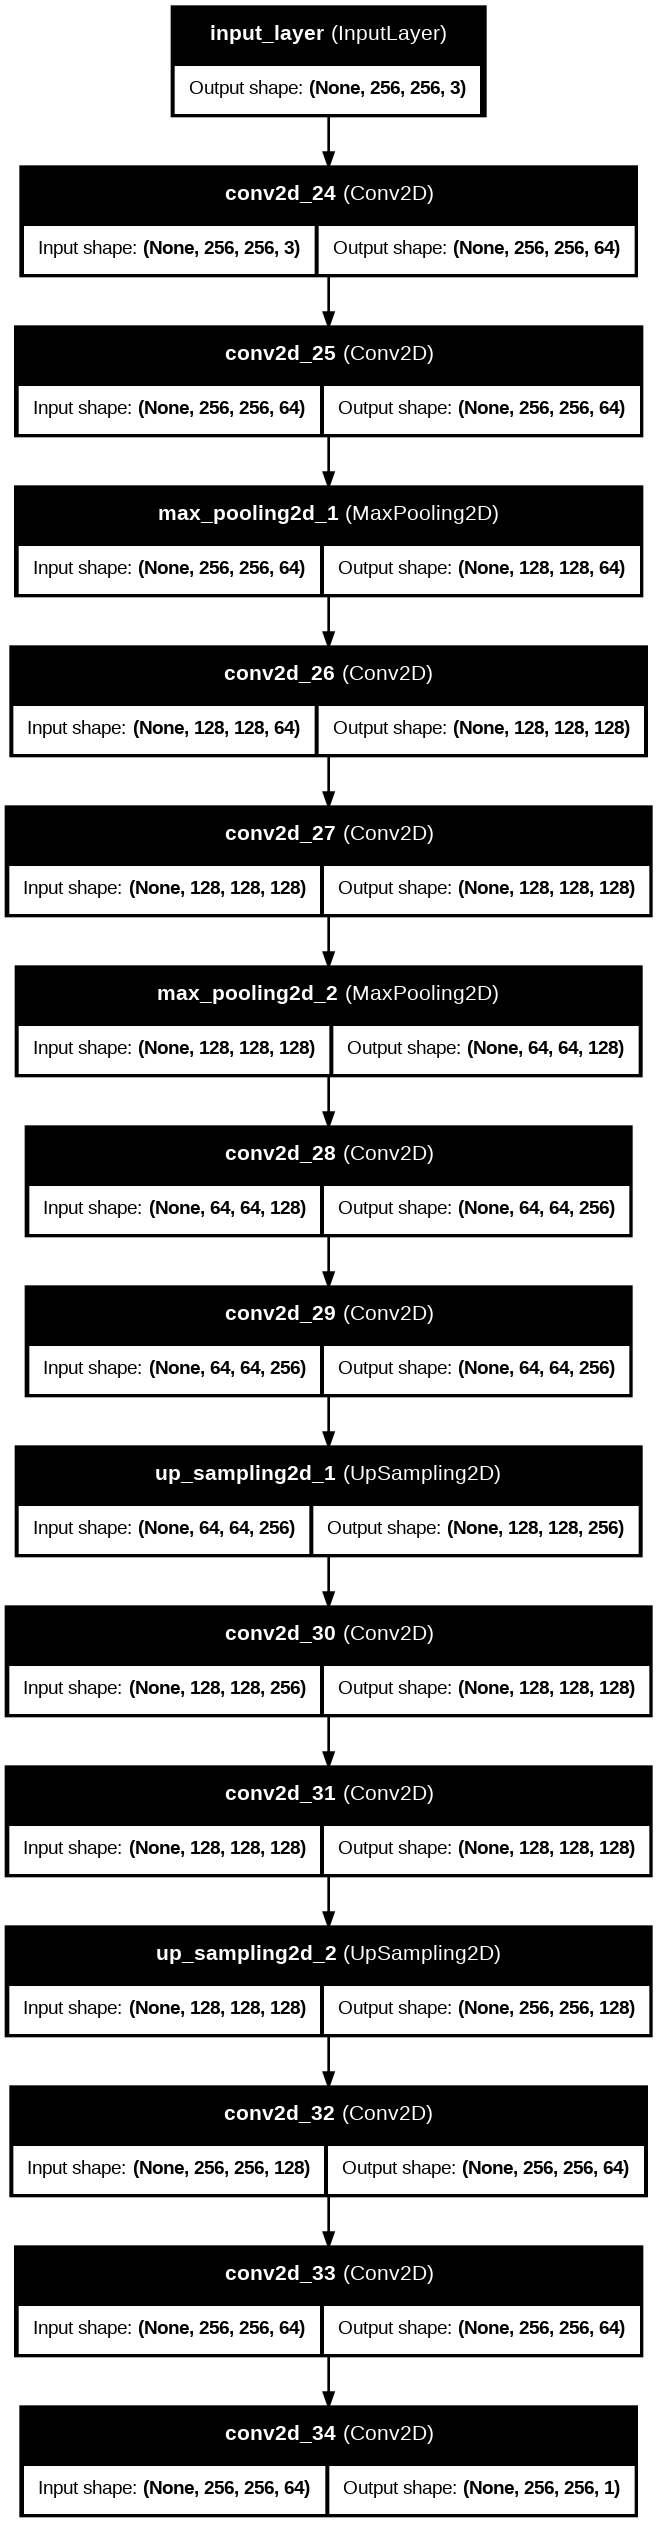

In [8]:
#визуализируем модель
tf.keras.utils.plot_model(
    model_func,
    to_file='model_architecture.png',
    show_shapes=True,
    show_dtype=False,
    show_layer_names=True,
    rankdir='TB',
    expand_nested=False,
    dpi=96
)

In [9]:
model_func.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 256, 256, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 256, 256, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 128, 128, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 128, 128, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 64, 64, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 64, 64, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 128, 128, 256)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_30 (Conv2D)              │ (None, 128, 128, 128)  │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 128, 128, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 256, 256, 128)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_32 (Conv2D)              │ (None, 256, 256, 64)   │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_33 (Conv2D)              │ (None, 256, 256, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_34 (Conv2D)              │ (None, 256, 256, 1)    │           577 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,699,329 (6.48 MB)

 Trainable params: 1,699,329 (6.48 MB)

 Non-trainable params: 0 (0.00 B)


**[ЗАДАНИЕ 4]** Реализуйте пайплайн обучения для такой модели (одной из): подготовка данных, лосс, обучение, тестирование. Используйте материалы из предыдущего практического урока. Обучите модель и сравните время обучения с временем обучения простой FCN из предыдущего урока.

Загружаю img


/tmp/ipython-input-147745261.py:9: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  img = imageio.imread('/content/sample_data/me_256.png')


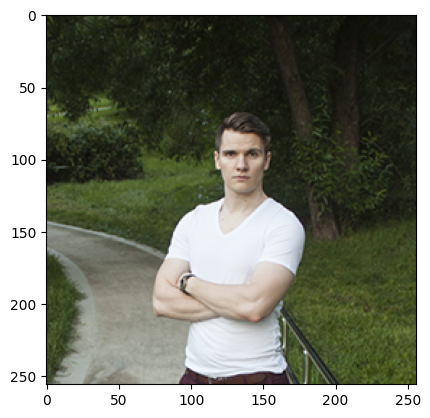

In [10]:
import random
import imageio
import numpy as np

%matplotlib inline
import matplotlib.pyplot as plt
import os
print("Загружаю img")
img = imageio.imread('/content/sample_data/me_256.png')
img = img.astype(np.float32) / 255
_=plt.imshow(img)

Загружаю img


/tmp/ipython-input-1991426343.py:3: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  img = imageio.imread('/content/sample_data/me_gt_256.png')


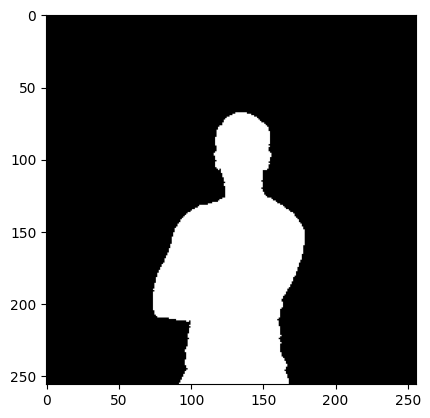

In [11]:
import os
print("Загружаю img")
img = imageio.imread('/content/sample_data/me_gt_256.png')
img = img.astype(np.float32) / 255
_=plt.imshow(img)

/tmp/ipython-input-512321571.py:1: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  gt = imageio.imread('/content/sample_data/me_gt_256.png')


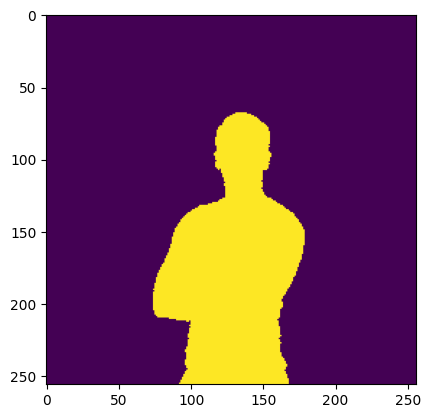

In [12]:
gt = imageio.imread('/content/sample_data/me_gt_256.png')
gt = gt.astype(np.float32) / 255.
gt = np.mean(gt, axis=2)[..., None]
_=plt.imshow(gt[...,0])

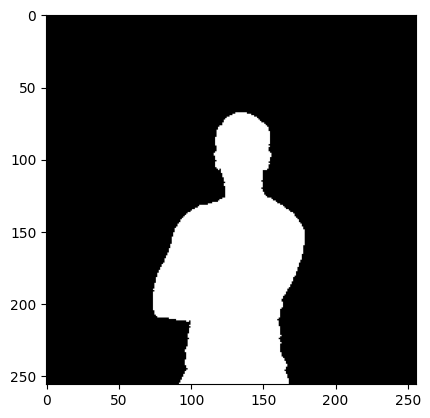

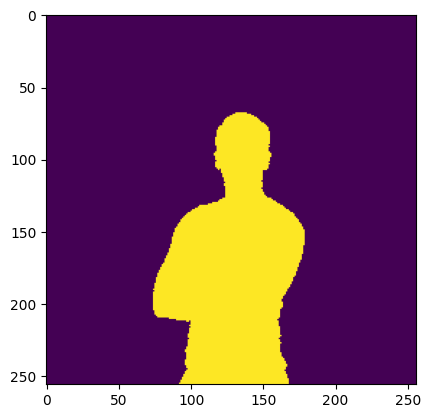

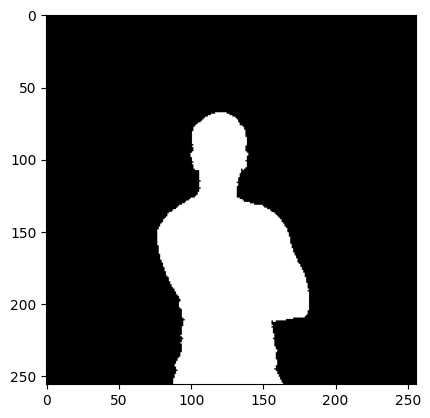

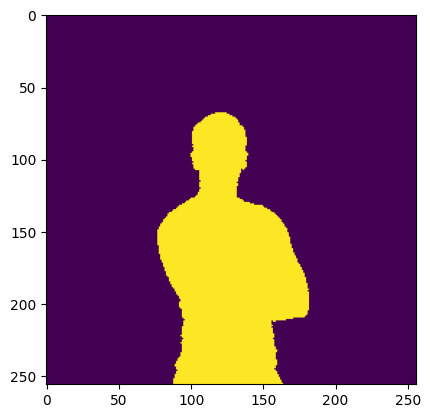

(<matplotlib.image.AxesImage at 0x7c2c7804fce0>, None)

In [13]:
train_x = np.stack((img, img[:,::-1,:]))
train_y = np.stack((gt, gt[:,::-1,:]))

plt.imshow(train_x[0]), plt.show()
plt.imshow(train_y[0][...,0]), plt.show()
plt.imshow(train_x[1]), plt.show()
plt.imshow(train_y[1][...,0]), plt.show()

In [14]:
%%time
model.compile(loss='binary_crossentropy', metrics=['accuracy'], optimizer='adam')
hist = model.fit(train_x,train_y, epochs=100, batch_size=1)

Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 13s 61ms/step - accuracy: 0.8410 - loss: 0.6923
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.8783 - loss: 0.7173
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.9451 - loss: 0.6256
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.8729 - loss: 0.6745
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.8159 - loss: 0.6641
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.8159 - loss: 0.6428
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.8159 - loss: 0.6028
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.8159 - loss: 0.4871
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.8159 - loss: 0.2913
Epoch 10/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.8159 - loss: 0.2458
Epoch 11/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.8159 - loss: 0.1893
Epoch 12/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.8159 - l

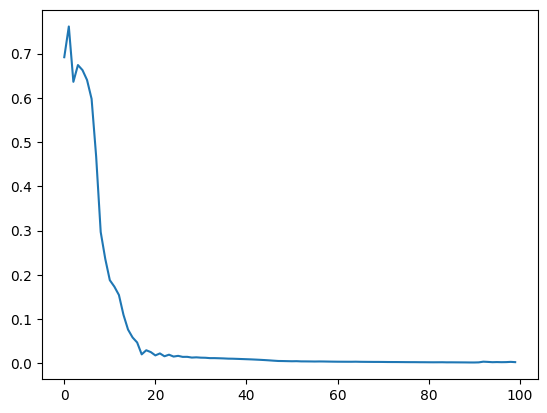

In [16]:
plt.plot(hist.history['loss'])

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


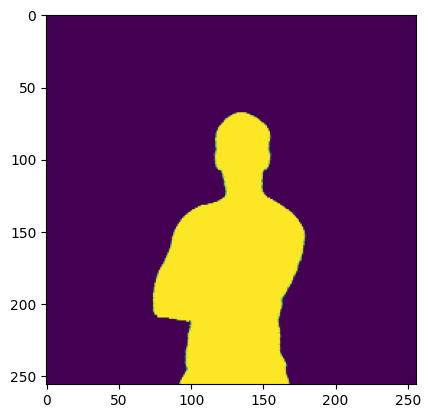

In [17]:
out = model.predict(img[None, ...])
_=plt.imshow(out[0, ..., 0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step


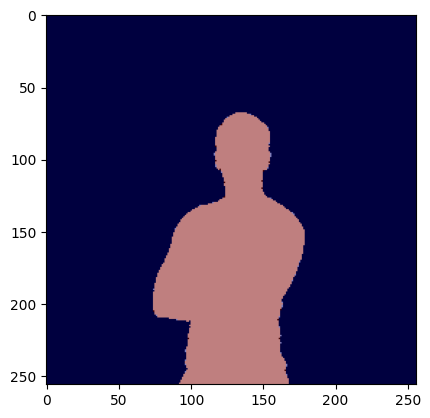

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


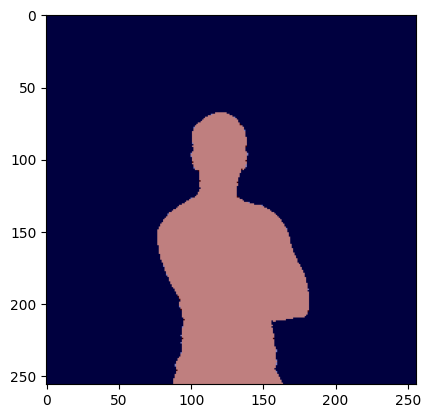

In [18]:
for sample in train_x:
    out = model.predict(sample[None, ...])
    seg_map = (out[0, ..., 0]>0.5).astype(np.float32)
    seg_map_clr = plt.get_cmap('jet')(seg_map)[..., :3]
    plt.imshow(sample*0.5 + seg_map_clr*0.5)
    plt.show()